# 03 - Clustering de Escolas por Desempenho no ENEM

Este notebook aplica algoritmos de clustering para identificar grupos de escolas com padrões semelhantes de desempenho no ENEM 2024.

## Objetivos
1. Determinar o número ótimo de clusters (k)
2. Aplicar e comparar múltiplos algoritmos de clustering
3. Avaliar a estabilidade e qualidade dos clusters
4. Visualizar e interpretar os resultados

## 1. Setup

Importação de bibliotecas, módulos locais e carregamento dos dados processados.

In [106]:
# Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Algoritmos de clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Métricas de avaliação
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score
)

# Redução de dimensionalidade
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Outros
import joblib
from pathlib import Path

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [107]:
# Importar módulos do src/
import sys
sys.path.append('../src')

# Tentar importar módulos customizados (se existirem)
try:
    from clustering import apply_kmeans, apply_dbscan
    from metrics import calculate_clustering_metrics
    from visualization import plot_clusters_2d
    print("✅ Módulos do src/ importados com sucesso!")
except ImportError as e:
    print(f"⚠️  Módulos do src/ não encontrados: {e}")
    print("    Usando apenas sklearn diretamente.")

⚠️  Módulos do src/ não encontrados: cannot import name 'apply_kmeans' from 'clustering' (C:\Users\leofs\Documents\ciencia_de_dados_2\enem_clustering\notebooks\../src\clustering.py)
    Usando apenas sklearn diretamente.


In [135]:
# Definir caminhos
DATA_PATH = Path('../data/processed')
MODELS_PATH = Path('../models')
MODELS_PATH.mkdir(exist_ok=True)

# Verificar arquivos disponíveis
print("Arquivos disponíveis em data/processed/:")
for f in DATA_PATH.glob('*'):
    print(f"  - {f.name}")

Arquivos disponíveis em data/processed/:
  - .gitkeep
  - dados_clustering.parquet
  - dados_escolas.parquet
  - escolas_com_clusters.csv
  - features.txt
  - labels_kmeans.npy
  - scaler.pkl


In [139]:
# Carregar dados processados
# Tentar encontrar o arquivo de dados processados
processed_files = list(DATA_PATH.glob('*.csv')) + list(DATA_PATH.glob('*.parquet'))

if len(processed_files) == 0:
    print("⚠️  Nenhum arquivo de dados processados encontrado.")
    print("    Por favor, execute o notebook 02_preprocessing.ipynb primeiro.")
    # Criar dados de exemplo para demonstração
    print("\n📝 Criando dados sintéticos para demonstração...")
    np.random.seed(42)
    n_samples = 1000
    
    # Simular features de escolas
    df = pd.DataFrame({
        'CO_ESCOLA': range(10000001, 10000001 + n_samples),
        'NU_NOTA_MT': np.random.normal(550, 100, n_samples),
        'NU_NOTA_CN': np.random.normal(530, 95, n_samples),
        'NU_NOTA_LC': np.random.normal(560, 90, n_samples),
        'NU_NOTA_CH': np.random.normal(540, 92, n_samples),
        'NU_NOTA_REDACAO': np.random.normal(580, 85, n_samples),
        'MEDIA_GERAL': np.random.normal(550, 80, n_samples),
        'TP_DEPENDENCIA_ADM_ESCOLA': np.random.choice([1, 2, 3, 4], n_samples, p=[0.05, 0.45, 0.30, 0.20]),
        'TP_LOCALIZACAO_ESCOLA': np.random.choice([1, 2], n_samples, p=[0.85, 0.15]),
        'Q006_RENDA_MEDIA': np.random.choice(range(1, 18), n_samples),
        'Q002_ESCOLARIDADE_MAE': np.random.choice(range(1, 8), n_samples),
        'TAXA_PARTICIPACAO': np.random.beta(8, 2, n_samples),
        'PERC_TREINEIROS': np.random.beta(2, 8, n_samples),
    })
    
    # Adicionar códigos de estado
    ufs = [11, 12, 13, 14, 15, 16, 17, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 35, 41, 42, 43, 50, 51, 52, 53]
    df['CO_UF_ESCOLA'] = np.random.choice(ufs, n_samples)
    
    # Limitar notas entre 0 e 1000
    nota_cols = ['NU_NOTA_MT', 'NU_NOTA_CN', 'NU_NOTA_LC', 'NU_NOTA_CH', 'NU_NOTA_REDACAO', 'MEDIA_GERAL']
    for col in nota_cols:
        df[col] = df[col].clip(0, 1000)
    
    # Criar features dummy para one-hot encoded
    for uf in ufs[:5]:  # Apenas alguns estados para exemplo
        df[f'UF_{uf}'] = (df['CO_UF_ESCOLA'] == uf).astype(int)
    
    for dep in [1, 2, 3, 4]:
        df[f'DEP_{dep}'] = (df['TP_DEPENDENCIA_ADM_ESCOLA'] == dep).astype(int)
    
    print(f"\n✅ Dados sintéticos criados: {df.shape[0]} escolas, {df.shape[1]} features")
    
else:
    # Carregar o primeiro arquivo encontrado
    file_path = processed_files[0]
    print(f"📂 Carregando: {file_path.name}")
    
    if file_path.suffix == '.csv':
        df = pd.read_csv(file_path)
    else:
        df = pd.read_parquet(file_path)
    
    print(f"✅ Dados carregados: {df.shape[0]} escolas, {df.shape[1]} features")

# Visualizar informações
print(f"\n📊 Shape: {df.shape}")
print(f"\n📋 Colunas: {list(df.columns)}")

📂 Carregando: escolas_complets_100percent.csv
✅ Dados carregados: 23023 escolas, 10 features

📊 Shape: (23023, 10)

📋 Colunas: ['CO_ESCOLA', 'TP_DEPENDENCIA_ADM_ESC', 'QTD_ALUNOS', 'MEDIA_GERAL', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO', 'cluster']


In [110]:
# Identificar features para clustering
# Excluir colunas de identificação e categóricas originais
exclude_cols = ['CO_ESCOLA', 'CO_UF_ESCOLA', 'TP_DEPENDENCIA_ADM_ESCOLA', 
                'TP_LOCALIZACAO_ESCOLA', 'cluster']

# Selecionar features numéricas (incluindo one-hot encoded)
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Garantir que todas são numéricas
X = df[feature_cols].select_dtypes(include=[np.number])

print(f"Features selecionadas para clustering ({len(X.columns)}):")
print(list(X.columns))
print(f"\n📊 Matriz de features: {X.shape}")

# Verificar valores faltantes
missing = X.isnull().sum()
if missing.sum() > 0:
    print(f"\n⚠️  Valores faltantes encontrados:")
    print(missing[missing > 0])
    # Preencher com média
    X = X.fillna(X.mean())
    print("    Preenchendo com média...")
else:
    print("\n✅ Sem valores faltantes")

Features selecionadas para clustering (8):
['TP_DEPENDENCIA_ADM_ESC', 'QTD_ALUNOS', 'MEDIA_GERAL', 'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

📊 Matriz de features: (23023, 8)

✅ Sem valores faltantes


## 2. Determinar Número de Clusters (k)

Vamos utilizar dois métodos para determinar o número ótimo de clusters:
- **Elbow Method (Método do Cotovelo)**: Analisa a inércia (soma dos quadrados intra-cluster)
- **Silhouette Analysis**: Mede a qualidade da separação entre clusters

In [111]:
# Definir range de k a testar
K_RANGE = range(2, 11)

# Armazenar resultados
results = {
    'k': [],
    'inertia': [],
    'silhouette': [],
    'davies_bouldin': [],
    'calinski_harabasz': []
}

print("🔍 Testando K-Means para diferentes valores de k...")
print("K | Inertia      | Silhouette | Davies-Bouldin | Calinski-Harabasz")
print("-" * 70)

for k in K_RANGE:
    # Aplicar K-Means
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42, max_iter=300)
    labels = kmeans.fit_predict(X)
    
    # Calcular métricas
    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    # Armazenar
    results['k'].append(k)
    results['inertia'].append(inertia)
    results['silhouette'].append(sil)
    results['davies_bouldin'].append(db)
    results['calinski_harabasz'].append(ch)
    
    print(f"{k:2d} | {inertia:12.2f} | {sil:10.3f} | {db:14.3f} | {ch:17.2f}")

results_df = pd.DataFrame(results)
print("\n✅ Avaliação completa!")

🔍 Testando K-Means para diferentes valores de k...
K | Inertia      | Silhouette | Davies-Bouldin | Calinski-Harabasz
----------------------------------------------------------------------
 2 | 278744838.50 |      0.520 |          0.706 |          33556.11
 3 | 195132531.78 |      0.367 |          0.909 |          28898.24
 4 | 156304805.12 |      0.329 |          0.973 |          25956.26
 5 | 137466977.89 |      0.279 |          1.108 |          22922.67
 6 | 119878287.59 |      0.292 |          1.015 |          21703.04
 7 | 109074486.32 |      0.263 |          1.078 |          20256.41
 8 | 101096487.86 |      0.270 |          1.049 |          18991.38
 9 |  93870880.81 |      0.248 |          1.101 |          18117.23
10 |  89141595.17 |      0.238 |          1.128 |          17093.51

✅ Avaliação completa!


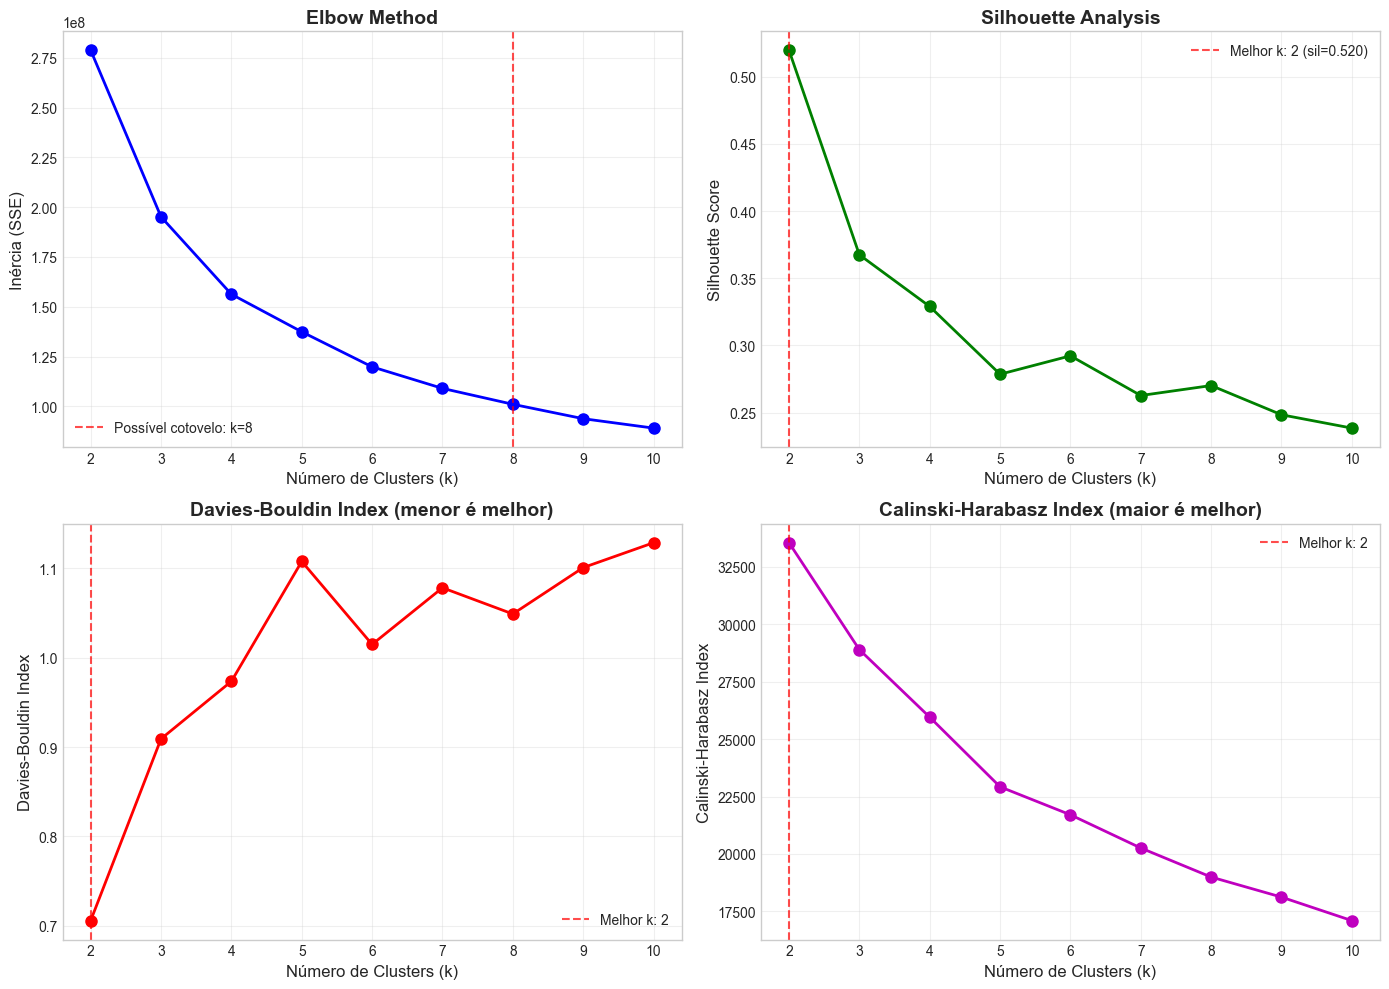


📊 Recomendações por método:
   • Elbow Method: k = 8
   • Silhouette Score: k = 2 (score = 0.520)
   • Davies-Bouldin: k = 2
   • Calinski-Harabasz: k = 2


In [112]:
# Plotar Elbow Method e Silhouette Score
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Elbow Method - Inertia
axes[0, 0].plot(results['k'], results['inertia'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inércia (SSE)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Destacar possível cotovelo
# Calcular diferenças segunda derivada (aproximada)
inertia_diff = np.diff(results['inertia'], 2)
elbow_k = results['k'][np.argmin(inertia_diff) + 1]
axes[0, 0].axvline(x=elbow_k, color='r', linestyle='--', alpha=0.7, label=f'Possível cotovelo: k={elbow_k}')
axes[0, 0].legend()

# 2. Silhouette Score
axes[0, 1].plot(results['k'], results['silhouette'], 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Analysis', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Destacar melhor valor
best_k_sil = results['k'][np.argmax(results['silhouette'])]
best_sil = max(results['silhouette'])
axes[0, 1].axvline(x=best_k_sil, color='r', linestyle='--', alpha=0.7, label=f'Melhor k: {best_k_sil} (sil={best_sil:.3f})')
axes[0, 1].legend()

# 3. Davies-Bouldin Index (menor é melhor)
axes[1, 0].plot(results['k'], results['davies_bouldin'], 'ro-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1, 0].set_title('Davies-Bouldin Index (menor é melhor)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

best_k_db = results['k'][np.argmin(results['davies_bouldin'])]
axes[1, 0].axvline(x=best_k_db, color='r', linestyle='--', alpha=0.7, label=f'Melhor k: {best_k_db}')
axes[1, 0].legend()

# 4. Calinski-Harabasz Index (maior é melhor)
axes[1, 1].plot(results['k'], results['calinski_harabasz'], 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Número de Clusters (k)', fontsize=12)
axes[1, 1].set_ylabel('Calinski-Harabasz Index', fontsize=12)
axes[1, 1].set_title('Calinski-Harabasz Index (maior é melhor)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

best_k_ch = results['k'][np.argmax(results['calinski_harabasz'])]
axes[1, 1].axvline(x=best_k_ch, color='r', linestyle='--', alpha=0.7, label=f'Melhor k: {best_k_ch}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('../reports/k_selection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Recomendações por método:")
print(f"   • Elbow Method: k = {elbow_k}")
print(f"   • Silhouette Score: k = {best_k_sil} (score = {best_sil:.3f})")
print(f"   • Davies-Bouldin: k = {best_k_db}")
print(f"   • Calinski-Harabasz: k = {best_k_ch}")

In [113]:
# Decisão do k ótimo
# Vamos considerar a maioria dos métodos
votes = [elbow_k, best_k_sil, best_k_db, best_k_ch]
from collections import Counter
k_optimal = Counter(votes).most_common(1)[0][0]

print(f"\n🎯 K ÓTIMO SELECIONADO: k = {k_optimal}")
print(f"\nJustificativa:")
print(f"   • Elbow Method sugere: k = {elbow_k}")
print(f"   • Silhouette Score máximo: k = {best_k_sil}")
print(f"   • Davies-Bouldin mínimo: k = {best_k_db}")
print(f"   • Calinski-Harabasz máximo: k = {best_k_ch}")
print(f"\n   ➡️  k = {k_optimal} foi escolhido pela maioria dos critérios")

# Salvar para uso posterior
OPTIMAL_K = k_optimal


🎯 K ÓTIMO SELECIONADO: k = 2

Justificativa:
   • Elbow Method sugere: k = 8
   • Silhouette Score máximo: k = 2
   • Davies-Bouldin mínimo: k = 2
   • Calinski-Harabasz máximo: k = 2

   ➡️  k = 2 foi escolhido pela maioria dos critérios


## 3. Aplicar K-Means

Aplicar K-Means com o k ótimo selecionado e avaliar estabilidade com diferentes seeds.

In [114]:
# Aplicar K-Means com k ótimo
print(f"🔧 Aplicando K-Means com k={OPTIMAL_K}...")

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    n_init=10,
    random_state=42,
    max_iter=300,
    algorithm='lloyd'
)

# Fit e predict
labels_kmeans = kmeans_final.fit_predict(X)

# Adicionar ao dataframe
df['cluster_kmeans'] = labels_kmeans

# Calcular métricas finais
sil_kmeans = silhouette_score(X, labels_kmeans)
db_kmeans = davies_bouldin_score(X, labels_kmeans)
ch_kmeans = calinski_harabasz_score(X, labels_kmeans)

print(f"\n✅ K-Means aplicado com sucesso!")
print(f"\n📊 Métricas do K-Means:")
print(f"   • Silhouette Score: {sil_kmeans:.4f}")
print(f"   • Davies-Bouldin Index: {db_kmeans:.4f}")
print(f"   • Calinski-Harabasz Index: {ch_kmeans:.2f}")
print(f"   • Inércia: {kmeans_final.inertia_:.2f}")

# Distribuição dos clusters
print(f"\n📈 Distribuição dos clusters:")
cluster_counts = pd.Series(labels_kmeans).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = count / len(labels_kmeans) * 100
    print(f"   • Cluster {cluster}: {count} escolas ({pct:.1f}%)")

🔧 Aplicando K-Means com k=2...

✅ K-Means aplicado com sucesso!

📊 Métricas do K-Means:
   • Silhouette Score: 0.5198
   • Davies-Bouldin Index: 0.7059
   • Calinski-Harabasz Index: 33556.11
   • Inércia: 278744838.50

📈 Distribuição dos clusters:
   • Cluster 0: 15529 escolas (67.4%)
   • Cluster 1: 7494 escolas (32.6%)


In [115]:
# Testar estabilidade com diferentes seeds
print("🔄 Testando estabilidade do K-Means com diferentes seeds...")

seeds = [0, 1, 2, 42, 100]
labels_per_seed = []

for seed in seeds:
    kmeans_test = KMeans(n_clusters=OPTIMAL_K, random_state=seed, n_init=10, max_iter=300)
    labels_test = kmeans_test.fit_predict(X)
    labels_per_seed.append(labels_test)
    print(f"   Seed {seed:3d}: Inertia = {kmeans_test.inertia_:.2f}")

# Calcular ARI entre todas as combinações de seeds
print(f"\n📊 Análise de Estabilidade (ARI - Adjusted Rand Index):")
print(f"   ARI > 0.8 indica alta estabilidade")
print(f"\nComparação entre seeds:")

ari_scores = []
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        ari = adjusted_rand_score(labels_per_seed[i], labels_per_seed[j])
        ari_scores.append(ari)
        print(f"   Seed {seeds[i]:3d} vs {seeds[j]:3d}: ARI = {ari:.4f}")

ari_mean = np.mean(ari_scores)
ari_std = np.std(ari_scores)

print(f"\n📈 Estatísticas de ARI:")
print(f"   • Média: {ari_mean:.4f}")
print(f"   • Desvio Padrão: {ari_std:.4f}")
print(f"   • Mínimo: {min(ari_scores):.4f}")
print(f"   • Máximo: {max(ari_scores):.4f}")

if ari_mean > 0.8:
    print(f"\n✅ ALTA ESTABILIDADE: ARI médio = {ari_mean:.4f} > 0.8")
elif ari_mean > 0.6:
    print(f"\n⚠️  ESTABILIDADE MODERADA: ARI médio = {ari_mean:.4f}")
else:
    print(f"\n❌ BAIXA ESTABILIDADE: ARI médio = {ari_mean:.4f} < 0.6")

🔄 Testando estabilidade do K-Means com diferentes seeds...
   Seed   0: Inertia = 278744637.40
   Seed   1: Inertia = 278744725.04
   Seed   2: Inertia = 278744725.04
   Seed  42: Inertia = 278744838.50
   Seed 100: Inertia = 278744637.40

📊 Análise de Estabilidade (ARI - Adjusted Rand Index):
   ARI > 0.8 indica alta estabilidade

Comparação entre seeds:
   Seed   0 vs   1: ARI = 0.9998
   Seed   0 vs   2: ARI = 0.9998
   Seed   0 vs  42: ARI = 0.9998
   Seed   0 vs 100: ARI = 1.0000
   Seed   1 vs   2: ARI = 1.0000
   Seed   1 vs  42: ARI = 1.0000
   Seed   1 vs 100: ARI = 0.9998
   Seed   2 vs  42: ARI = 1.0000
   Seed   2 vs 100: ARI = 0.9998
   Seed  42 vs 100: ARI = 0.9998

📈 Estatísticas de ARI:
   • Média: 0.9999
   • Desvio Padrão: 0.0001
   • Mínimo: 0.9998
   • Máximo: 1.0000

✅ ALTA ESTABILIDADE: ARI médio = 0.9999 > 0.8


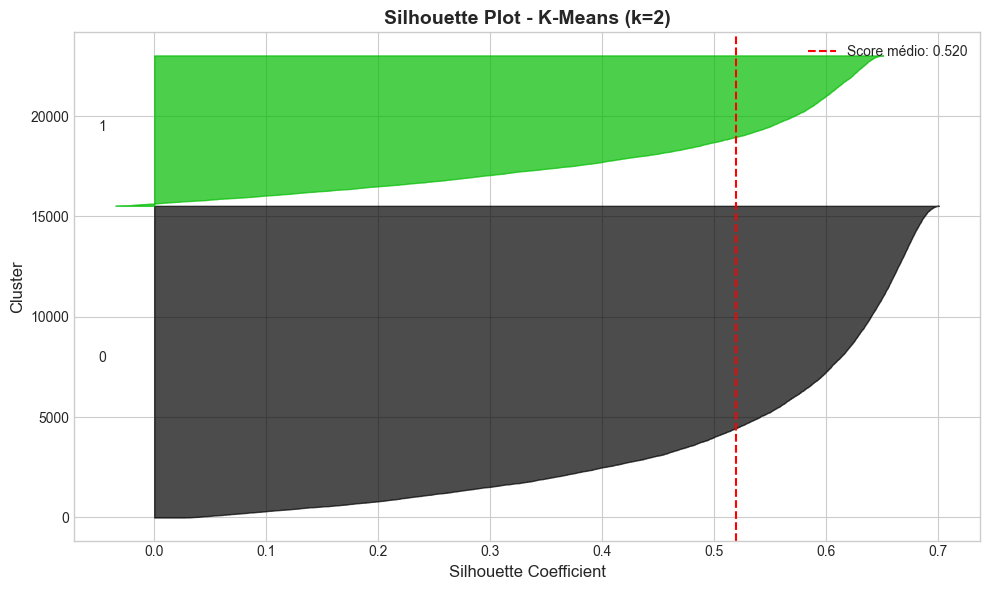

In [116]:
# Visualizar Silhouette Plot para K-Means
from sklearn.metrics import silhouette_samples

fig, ax = plt.subplots(figsize=(10, 6))

silhouette_vals = silhouette_samples(X, labels_kmeans)
y_lower, y_upper = 0, 0

for i in range(OPTIMAL_K):
    cluster_silhouette_vals = silhouette_vals[labels_kmeans == i]
    cluster_silhouette_vals.sort()
    y_upper += len(cluster_silhouette_vals)
    color = plt.cm.nipy_spectral(float(i) / OPTIMAL_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_silhouette_vals), str(i))
    y_lower = y_upper

ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot - K-Means (k={OPTIMAL_K})', fontsize=14, fontweight='bold')
ax.axvline(x=sil_kmeans, color="red", linestyle="--", 
           label=f'Score médio: {sil_kmeans:.3f}')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../reports/silhouette_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Aplicar DBSCAN

DBSCAN é um algoritmo baseado em densidade que pode identificar outliers e clusters de formas arbitrárias.

📈 Calculando k-distance graph para determinar eps...


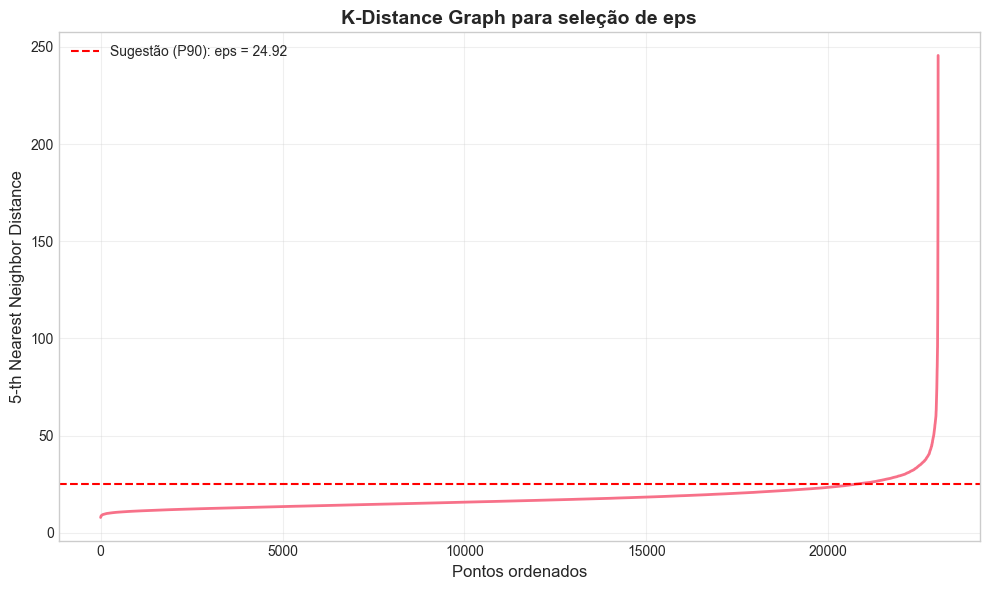


💡 Sugestão de eps baseada no percentil 90: 24.917


In [117]:
# Encontrar eps via k-distance graph
print("📈 Calculando k-distance graph para determinar eps...")

# Usar k = min_samples (padrão = 5)
min_samples = 5
k = min_samples

# Calcular distâncias para o k-ésimo vizinho mais próximo
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Ordenar distâncias
distances = np.sort(distances[:, k-1], axis=0)

# Plotar k-distance graph
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(distances, linewidth=2)
ax.set_xlabel('Pontos ordenados', fontsize=12)
ax.set_ylabel(f'{k}-th Nearest Neighbor Distance', fontsize=12)
ax.set_title('K-Distance Graph para seleção de eps', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Tentar identificar o "cotovelo" automaticamente
# (simplificado: usar percentil 90 como sugestão)
eps_suggested = np.percentile(distances, 90)
ax.axhline(y=eps_suggested, color='r', linestyle='--', 
           label=f'Sugestão (P90): eps = {eps_suggested:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Sugestão de eps baseada no percentil 90: {eps_suggested:.3f}")

In [118]:
# Aplicar DBSCAN com eps selecionado
# Testar alguns valores de eps próximos à sugestão
eps_values = [eps_suggested * 0.8, eps_suggested, eps_suggested * 1.2, eps_suggested * 1.5]

print("🔧 Testando diferentes valores de eps para DBSCAN...")
print(f"\n{'Eps':>8} | {'Clusters':>8} | {'Outliers':>8} | {'% Outliers':>10}")
print("-" * 50)

best_dbscan = None
best_dbscan_score = -1

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels_db = dbscan.fit_predict(X)
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_outliers = list(labels_db).count(-1)
    pct_outliers = n_outliers / len(labels_db) * 100
    
    print(f"{eps:8.3f} | {n_clusters:8d} | {n_outliers:8d} | {pct_outliers:9.1f}%")
    
    # Calcular silhouette score (apenas para pontos não-outliers)
    if n_clusters >= 2 and n_outliers < len(labels_db) * 0.5:
        mask = labels_db != -1
        if mask.sum() > n_clusters:
            score = silhouette_score(X[mask], labels_db[mask])
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan = (eps, dbscan, labels_db, n_clusters, n_outliers)

# Selecionar melhor DBSCAN
if best_dbscan:
    eps_final, dbscan_final, labels_dbscan, n_clusters_db, n_outliers_db = best_dbscan
    print(f"\n✅ Melhor DBSCAN: eps = {eps_final:.3f}")
else:
    # Fallback para o valor do meio
    eps_final = eps_suggested
    dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples)
    labels_dbscan = dbscan_final.fit_predict(X)
    n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
    n_outliers_db = list(labels_dbscan).count(-1)
    print(f"\n⚠️  Usando DBSCAN padrão: eps = {eps_final:.3f}")

🔧 Testando diferentes valores de eps para DBSCAN...

     Eps | Clusters | Outliers | % Outliers
--------------------------------------------------
  19.934 |       37 |     3378 |      14.7%
  24.917 |       15 |     1130 |       4.9%
  29.901 |       10 |      460 |       2.0%
  37.376 |        4 |      177 |       0.8%

✅ Melhor DBSCAN: eps = 37.376


In [119]:
# Análise detalhada do DBSCAN final
print(f"\n📊 Resultados do DBSCAN (eps={eps_final:.3f}, min_samples={min_samples}):")
print(f"   • Número de clusters encontrados: {n_clusters_db}")
print(f"   • Número de outliers (ruído): {n_outliers_db}")
print(f"   • Percentual de outliers: {n_outliers_db/len(labels_dbscan)*100:.1f}%")

# Adicionar ao dataframe
df['cluster_dbscan'] = labels_dbscan

# Calcular métricas (excluindo outliers)
mask_no_outliers = labels_dbscan != -1
if mask_no_outliers.sum() > n_clusters_db and n_clusters_db >= 2:
    sil_dbscan = silhouette_score(X[mask_no_outliers], labels_dbscan[mask_no_outliers])
    db_dbscan = davies_bouldin_score(X[mask_no_outliers], labels_dbscan[mask_no_outliers])
    ch_dbscan = calinski_harabasz_score(X[mask_no_outliers], labels_dbscan[mask_no_outliers])
    
    print(f"\n📈 Métricas (sem outliers):")
    print(f"   • Silhouette Score: {sil_dbscan:.4f}")
    print(f"   • Davies-Bouldin Index: {db_dbscan:.4f}")
    print(f"   • Calinski-Harabasz Index: {ch_dbscan:.2f}")
else:
    print(f"\n⚠️  Métricas não calculadas: número insuficiente de clusters ou muitos outliers")
    sil_dbscan = db_dbscan = ch_dbscan = None

# Distribuição dos clusters (incluindo outliers como -1)
print(f"\n📈 Distribuição dos clusters:")
dbscan_counts = pd.Series(labels_dbscan).value_counts().sort_index()
for cluster, count in dbscan_counts.items():
    pct = count / len(labels_dbscan) * 100
    label = 'Outliers' if cluster == -1 else f'Cluster {cluster}'
    print(f"   • {label}: {count} escolas ({pct:.1f}%)")


📊 Resultados do DBSCAN (eps=37.376, min_samples=5):
   • Número de clusters encontrados: 4
   • Número de outliers (ruído): 177
   • Percentual de outliers: 0.8%

📈 Métricas (sem outliers):
   • Silhouette Score: 0.3209
   • Davies-Bouldin Index: 0.6601
   • Calinski-Harabasz Index: 31.26

📈 Distribuição dos clusters:
   • Outliers: 177 escolas (0.8%)
   • Cluster 0: 22828 escolas (99.2%)
   • Cluster 1: 5 escolas (0.0%)
   • Cluster 2: 7 escolas (0.0%)
   • Cluster 3: 6 escolas (0.0%)


## 5. Aplicar Clustering Hierárquico (Hierarchical)

Clustering hierárquico aglomerativo com linkage='ward' para minimizar a variância intra-cluster.

🌳 Criando dendrograma (usando amostra para performance)...


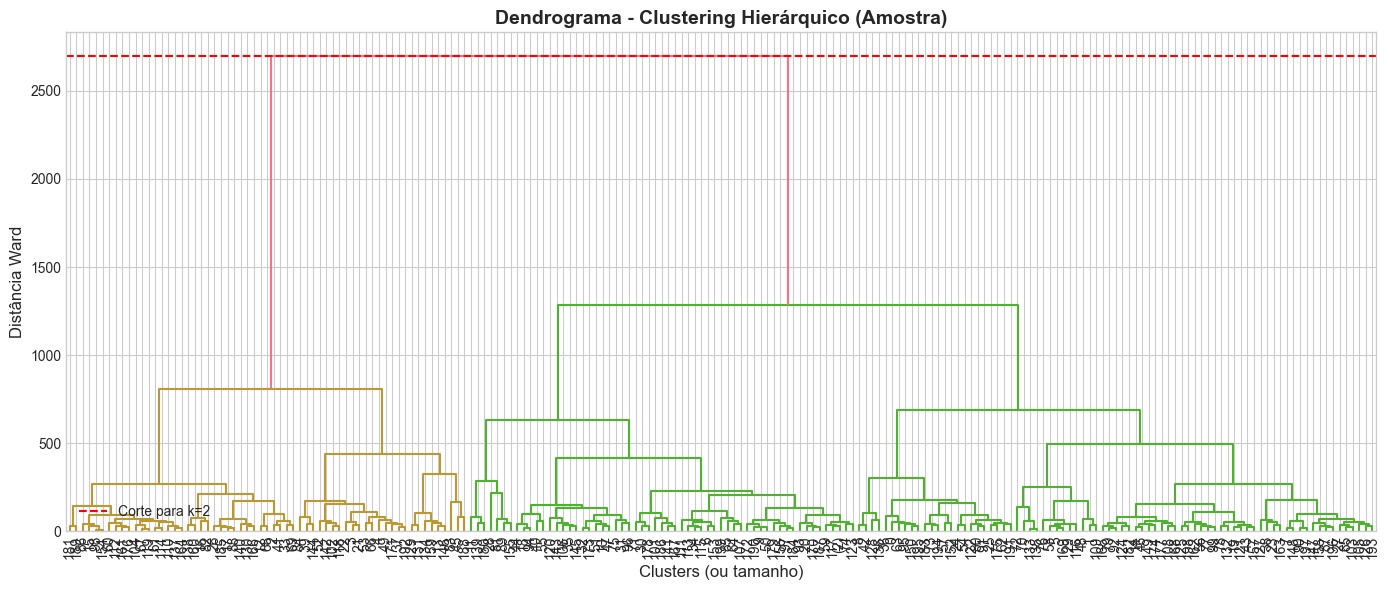


✅ Dendrograma gerado com amostra de 200 escolas


In [120]:
# Criar dendrograma (amostra para visualização)
print("🌳 Criando dendrograma (usando amostra para performance)...")

# Usar amostra para dendrograma se muitos dados
sample_size = min(200, len(X))
sample_idx = np.random.choice(len(X), sample_size, replace=False)
X_sample = X.iloc[sample_idx] if hasattr(X, 'iloc') else X[sample_idx]

# Calcular linkage
linkage_matrix = linkage(X_sample, method='ward')

# Plotar dendrograma
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_matrix, truncate_mode='level', p=10, 
           show_leaf_counts=True, leaf_font_size=10, ax=ax)
ax.set_xlabel('Clusters (ou tamanho)', fontsize=12)
ax.set_ylabel('Distância Ward', fontsize=12)
ax.set_title('Dendrograma - Clustering Hierárquico (Amostra)', fontsize=14, fontweight='bold')

# Linha de corte sugerida baseada no k ótimo
ax.axhline(y=linkage_matrix[-(OPTIMAL_K-1), 2] if len(linkage_matrix) >= OPTIMAL_K-1 else linkage_matrix[-1, 2], 
           color='r', linestyle='--', label=f'Corte para k={OPTIMAL_K}')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/dendrogram_hierarchical.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Dendrograma gerado com amostra de {sample_size} escolas")

In [121]:
# Aplicar AgglomerativeClustering com k ótimo
print(f"🔧 Aplicando AgglomerativeClustering com k={OPTIMAL_K}...")

hierarchical = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage='ward'
)

labels_hierarchical = hierarchical.fit_predict(X)
df['cluster_hierarchical'] = labels_hierarchical

# Calcular métricas
sil_hierarchical = silhouette_score(X, labels_hierarchical)
db_hierarchical = davies_bouldin_score(X, labels_hierarchical)
ch_hierarchical = calinski_harabasz_score(X, labels_hierarchical)

print(f"\n✅ Clustering Hierárquico aplicado com sucesso!")
print(f"\n📊 Métricas do Hierárquico:")
print(f"   • Silhouette Score: {sil_hierarchical:.4f}")
print(f"   • Davies-Bouldin Index: {db_hierarchical:.4f}")
print(f"   • Calinski-Harabasz Index: {ch_hierarchical:.2f}")

# Distribuição dos clusters
print(f"\n📈 Distribuição dos clusters:")
hierarchical_counts = pd.Series(labels_hierarchical).value_counts().sort_index()
for cluster, count in hierarchical_counts.items():
    pct = count / len(labels_hierarchical) * 100
    print(f"   • Cluster {cluster}: {count} escolas ({pct:.1f}%)")

🔧 Aplicando AgglomerativeClustering com k=2...

✅ Clustering Hierárquico aplicado com sucesso!

📊 Métricas do Hierárquico:
   • Silhouette Score: 0.4978
   • Davies-Bouldin Index: 0.6366
   • Calinski-Harabasz Index: 23408.78

📈 Distribuição dos clusters:
   • Cluster 0: 18628 escolas (80.9%)
   • Cluster 1: 4395 escolas (19.1%)


In [122]:
# Comparar Hierárquico com K-Means (usando ARI)
ari_hier_kmeans = adjusted_rand_score(labels_hierarchical, labels_kmeans)

print(f"\n🔗 Comparação Hierárquico vs K-Means:")
print(f"   • ARI (Adjusted Rand Index): {ari_hier_kmeans:.4f}")

if ari_hier_kmeans > 0.8:
    print(f"   ✅ Alta concordância entre algoritmos")
elif ari_hier_kmeans > 0.5:
    print(f"   ⚠️  Concordância moderada")
else:
    print(f"   ❌ Baixa concordância - clusters bastante diferentes")


🔗 Comparação Hierárquico vs K-Means:
   • ARI (Adjusted Rand Index): 0.5113
   ⚠️  Concordância moderada


## 6. Aplicar Gaussian Mixture Model (GMM)

GMM é um modelo probabilístico que assume que os dados são gerados a partir de uma mistura de distribuições Gaussianas.

In [123]:
# Aplicar GMM com n_components = k ótimo
print(f"🔧 Aplicando Gaussian Mixture Model com n_components={OPTIMAL_K}...")

gmm = GaussianMixture(
    n_components=OPTIMAL_K,
    covariance_type='full',
    random_state=42,
    max_iter=100,
    n_init=5
)

# Fit e predict
gmm.fit(X)
labels_gmm = gmm.predict(X)
df['cluster_gmm'] = labels_gmm

# Calcular métricas
sil_gmm = silhouette_score(X, labels_gmm)
db_gmm = davies_bouldin_score(X, labels_gmm)
ch_gmm = calinski_harabasz_score(X, labels_gmm)

print(f"\n✅ GMM aplicado com sucesso!")
print(f"\n📊 Métricas do GMM:")
print(f"   • Silhouette Score: {sil_gmm:.4f}")
print(f"   • Davies-Bouldin Index: {db_gmm:.4f}")
print(f"   • Calinski-Harabasz Index: {ch_gmm:.2f}")
print(f"   • Log-Likelihood: {gmm.lower_bound_:.2f}")

# BIC e AIC
bic = gmm.bic(X)
aic = gmm.aic(X)
print(f"   • BIC (Bayesian Information Criterion): {bic:.2f}")
print(f"   • AIC (Akaike Information Criterion): {aic:.2f}")
print(f"\n   ℹ️  BIC e AIC: valores menores indicam melhor modelo")

# Distribuição dos clusters
print(f"\n📈 Distribuição dos clusters:")
gmm_counts = pd.Series(labels_gmm).value_counts().sort_index()
for cluster, count in gmm_counts.items():
    pct = count / len(labels_gmm) * 100
    print(f"   • Cluster {cluster}: {count} escolas ({pct:.1f}%)")

🔧 Aplicando Gaussian Mixture Model com n_components=2...

✅ GMM aplicado com sucesso!

📊 Métricas do GMM:
   • Silhouette Score: 0.4484
   • Davies-Bouldin Index: 0.8105
   • Calinski-Harabasz Index: 23926.04
   • Log-Likelihood: -18.71
   • BIC (Bayesian Information Criterion): 862540.66
   • AIC (Akaike Information Criterion): 861824.72

   ℹ️  BIC e AIC: valores menores indicam melhor modelo

📈 Distribuição dos clusters:
   • Cluster 0: 15777 escolas (68.5%)
   • Cluster 1: 7246 escolas (31.5%)


📊 Calculando BIC/AIC para diferentes números de componentes...


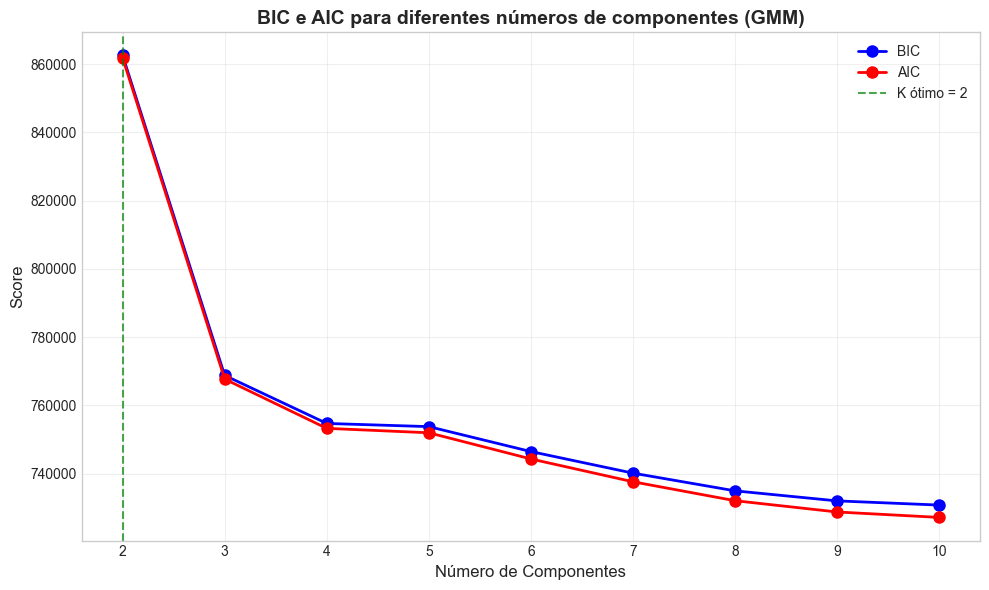


💡 Sugestões baseadas em critérios de informação:
   • Melhor k por BIC: 10
   • Melhor k por AIC: 10
   • K selecionado anteriormente: 2


In [124]:
# Testar diferentes números de componentes para GMM (BIC/AIC)
print("📊 Calculando BIC/AIC para diferentes números de componentes...")

n_components_range = range(2, 11)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm_test = GaussianMixture(n_components=n, covariance_type='full', 
                               random_state=42, max_iter=100, n_init=3)
    gmm_test.fit(X)
    bic_scores.append(gmm_test.bic(X))
    aic_scores.append(gmm_test.aic(X))

# Plotar BIC e AIC
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_components_range, bic_scores, 'bo-', label='BIC', linewidth=2, markersize=8)
ax.plot(n_components_range, aic_scores, 'ro-', label='AIC', linewidth=2, markersize=8)
ax.axvline(x=OPTIMAL_K, color='g', linestyle='--', alpha=0.7, label=f'K ótimo = {OPTIMAL_K}')
ax.set_xlabel('Número de Componentes', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('BIC e AIC para diferentes números de componentes (GMM)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/gmm_bic_aic.png', dpi=150, bbox_inches='tight')
plt.show()

best_bic_k = list(n_components_range)[np.argmin(bic_scores)]
best_aic_k = list(n_components_range)[np.argmin(aic_scores)]

print(f"\n💡 Sugestões baseadas em critérios de informação:")
print(f"   • Melhor k por BIC: {best_bic_k}")
print(f"   • Melhor k por AIC: {best_aic_k}")
print(f"   • K selecionado anteriormente: {OPTIMAL_K}")

In [125]:
# Comparar GMM com K-Means
ari_gmm_kmeans = adjusted_rand_score(labels_gmm, labels_kmeans)

print(f"\n🔗 Comparação GMM vs K-Means:")
print(f"   • ARI (Adjusted Rand Index): {ari_gmm_kmeans:.4f}")

if ari_gmm_kmeans > 0.8:
    print(f"   ✅ Alta concordância - GMM e K-Means encontram padrões similares")
elif ari_gmm_kmeans > 0.5:
    print(f"   ⚠️  Concordância moderada")
else:
    print(f"   ❌ Baixa concordância - clusters bastante diferentes")
    print(f"      Isso pode indicar que os dados não são bem modelados por Gaussianas esféricas")


🔗 Comparação GMM vs K-Means:
   • ARI (Adjusted Rand Index): 0.6849
   ⚠️  Concordância moderada


## 7. Comparação de Algoritmos

Tabela comparativa de métricas para todos os algoritmos aplicados.

In [126]:
# Criar tabela comparativa
comparison_data = {
    'Algoritmo': ['K-Means', 'DBSCAN', 'Hierarchical', 'GMM'],
    'Silhouette Score': [sil_kmeans, sil_dbscan if sil_dbscan else np.nan, sil_hierarchical, sil_gmm],
    'Davies-Bouldin ↓': [db_kmeans, db_dbscan if db_dbscan else np.nan, db_hierarchical, db_gmm],
    'Calinski-Harabasz ↑': [ch_kmeans, ch_dbscan if ch_dbscan else np.nan, ch_hierarchical, ch_gmm],
    'Nº Clusters': [OPTIMAL_K, n_clusters_db, OPTIMAL_K, OPTIMAL_K],
    'Outliers': [0, n_outliers_db, 0, 0],
    '% Outliers': ['0.0%', f"{n_outliers_db/len(labels_dbscan)*100:.1f}%", '0.0%', '0.0%']
}

comparison_df = pd.DataFrame(comparison_data)

print("📊 COMPARAÇÃO DE ALGORITMOS DE CLUSTERING")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("\nLegenda:")
print("  • Silhouette: [-1, 1] - valores > 0.25 indicam estrutura razoável")
print("  • Davies-Bouldin: [0, ∞) - valores menores são melhores")
print("  • Calinski-Harabasz: [0, ∞) - valores maiores são melhores")

📊 COMPARAÇÃO DE ALGORITMOS DE CLUSTERING
   Algoritmo  Silhouette Score  Davies-Bouldin ↓  Calinski-Harabasz ↑  Nº Clusters  Outliers % Outliers
     K-Means          0.519766          0.705889         33556.107222            2         0       0.0%
      DBSCAN          0.320937          0.660113            31.264444            4       177       0.8%
Hierarchical          0.497781          0.636646         23408.783635            2         0       0.0%
         GMM          0.448417          0.810499         23926.041582            2         0       0.0%

Legenda:
  • Silhouette: [-1, 1] - valores > 0.25 indicam estrutura razoável
  • Davies-Bouldin: [0, ∞) - valores menores são melhores
  • Calinski-Harabasz: [0, ∞) - valores maiores são melhores


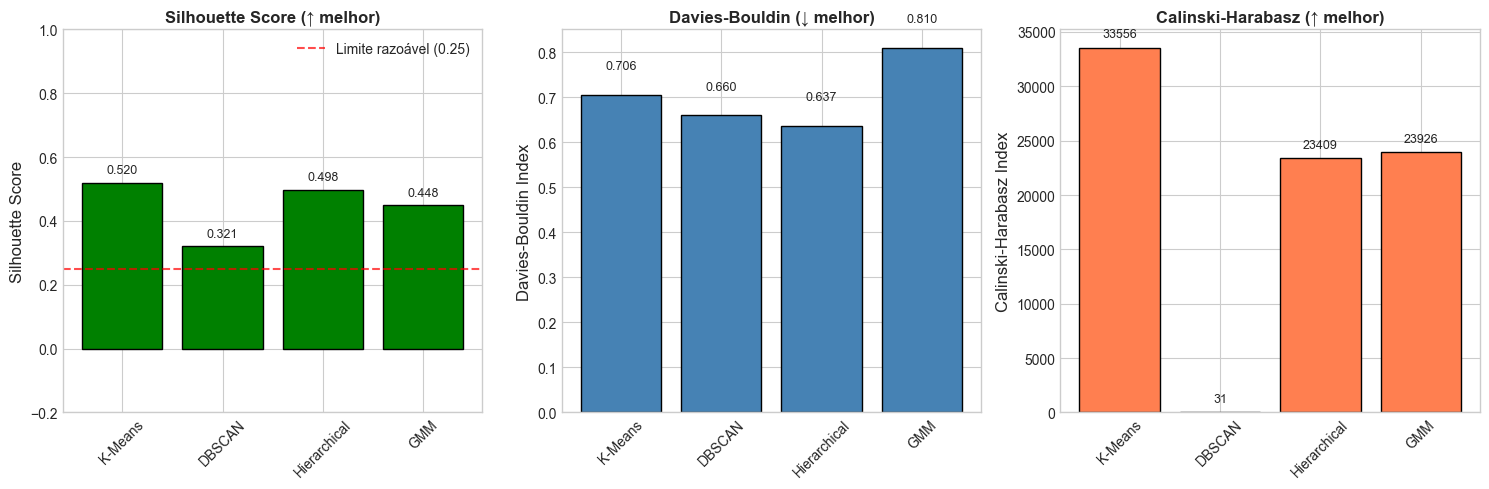

In [127]:
# Visualização comparativa das métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algorithms = ['K-Means', 'DBSCAN', 'Hierarchical', 'GMM']

# Silhouette Score (quanto maior, melhor)
sil_values = [sil_kmeans, sil_dbscan if sil_dbscan else 0, sil_hierarchical, sil_gmm]
colors_sil = ['green' if v >= 0.25 else 'orange' if v >= 0 else 'red' for v in sil_values]
axes[0].bar(algorithms, sil_values, color=colors_sil, edgecolor='black')
axes[0].axhline(y=0.25, color='r', linestyle='--', alpha=0.7, label='Limite razoável (0.25)')
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score (↑ melhor)', fontsize=12, fontweight='bold')
axes[0].set_ylim([-0.2, 1])
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
for i, v in enumerate(sil_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Davies-Bouldin (quanto menor, melhor)
db_values = [db_kmeans, db_dbscan if db_dbscan else np.nan, db_hierarchical, db_gmm]
valid_db = [(i, v) for i, v in enumerate(db_values) if not np.isnan(v)]
if valid_db:
    axes[1].bar([algorithms[i] for i, _ in valid_db], [v for _, v in valid_db], 
                color='steelblue', edgecolor='black')
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Davies-Bouldin (↓ melhor)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
for i, v in valid_db:
    axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

# Calinski-Harabasz (quanto maior, melhor)
ch_values = [ch_kmeans, ch_dbscan if ch_dbscan else 0, ch_hierarchical, ch_gmm]
axes[2].bar(algorithms, ch_values, color='coral', edgecolor='black')
axes[2].set_ylabel('Calinski-Harabasz Index', fontsize=12)
axes[2].set_title('Calinski-Harabasz (↑ melhor)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
for i, v in enumerate(ch_values):
    if v > 0:
        axes[2].text(i, v + max(ch_values)*0.02, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/algorithms_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [128]:
# Escolher melhor algoritmo baseado nas métricas
print("\n🎯 SELEÇÃO DO MELHOR ALGORITMO")
print("=" * 50)

# Criar scoring baseado nas métricas (normalizadas)
# Silhouette: maior é melhor (normalizado 0-1)
# Davies-Bouldin: menor é melhor (inverte e normaliza)
# Calinski-Harabasz: maior é melhor (normaliza por max)

scores = {}

# K-Means
scores['K-Means'] = {
    'silhouette': sil_kmeans,
    'davies_bouldin': 1 / (1 + db_kmeans),  # Inverso para comparar
    'stability': ari_mean,
    'interpretability': 1.0  # K-Means é muito interpretável
}

# DBSCAN
if sil_dbscan:
    scores['DBSCAN'] = {
        'silhouette': sil_dbscan,
        'davies_bouldin': 1 / (1 + db_dbscan),
        'stability': 0.5,  # DBSCAN pode ser sensível a parâmetros
        'interpretability': 0.7  # Menos interpretável (clusters arbitrários)
    }

# Hierarchical
scores['Hierarchical'] = {
    'silhouette': sil_hierarchical,
    'davies_bouldin': 1 / (1 + db_hierarchical),
    'stability': ari_hier_kmeans,  # Concordância com K-Means como proxy
    'interpretability': 0.9  # Dendrograma ajuda na interpretação
}

# GMM
scores['GMM'] = {
    'silhouette': sil_gmm,
    'davies_bouldin': 1 / (1 + db_gmm),
    'stability': ari_gmm_kmeans,
    'interpretability': 0.8  # Modelo probabilístico é interpretável
}

# Calcular score ponderado
weights = {'silhouette': 0.3, 'davies_bouldin': 0.25, 'stability': 0.25, 'interpretability': 0.2}

final_scores = {}
for algo, metrics in scores.items():
    final_scores[algo] = sum(metrics[k] * weights[k] for k in weights.keys())

# Ordenar por score
ranking = sorted(final_scores.items(), key=lambda x: x[1], reverse=True)

print("\nRanking dos Algoritmos (score ponderado):")
for i, (algo, score) in enumerate(ranking, 1):
    print(f"  {i}. {algo}: {score:.4f}")

best_algorithm = ranking[0][0]
print(f"\n🏆 MELHOR ALGORITMO: {best_algorithm}")


🎯 SELEÇÃO DO MELHOR ALGORITMO

Ranking dos Algoritmos (score ponderado):
  1. K-Means: 0.7525
  2. Hierarchical: 0.6099
  3. GMM: 0.6038
  4. DBSCAN: 0.5119

🏆 MELHOR ALGORITMO: K-Means


In [129]:
# Salvar o melhor modelo
print(f"\n💾 Salvando modelo escolhido ({best_algorithm})...")

# Selecionar modelo e labels baseado no melhor algoritmo
if best_algorithm == 'K-Means':
    best_model = kmeans_final
    best_labels = labels_kmeans
    model_filename = 'kmeans_model.pkl'
elif best_algorithm == 'DBSCAN':
    best_model = dbscan_final
    best_labels = labels_dbscan
    model_filename = 'dbscan_model.pkl'
elif best_algorithm == 'Hierarchical':
    best_model = hierarchical
    best_labels = labels_hierarchical
    model_filename = 'hierarchical_model.pkl'
else:  # GMM
    best_model = gmm
    best_labels = labels_gmm
    model_filename = 'gmm_model.pkl'

# Salvar modelo
model_path = MODELS_PATH / model_filename
joblib.dump(best_model, model_path)
print(f"   ✅ Modelo salvo em: {model_path}")

# Salvar dados com clusters
df['cluster'] = best_labels
output_path = DATA_PATH / 'escolas_com_clusters.csv'
df.to_csv(output_path, index=False)
print(f"   ✅ Dados com clusters salvos em: {output_path}")

# Salvar relatório de comparação
comparison_df.to_csv(MODELS_PATH / 'algorithm_comparison.csv', index=False)
print(f"   ✅ Relatório comparativo salvo em: {MODELS_PATH / 'algorithm_comparison.csv'}")


💾 Salvando modelo escolhido (K-Means)...
   ✅ Modelo salvo em: ..\models\kmeans_model.pkl
   ✅ Dados com clusters salvos em: ..\data\processed\escolas_com_clusters.csv
   ✅ Relatório comparativo salvo em: ..\models\algorithm_comparison.csv


## 8. Visualização dos Clusters

Aplicação de PCA e t-SNE para visualização 2D dos clusters.

In [130]:
# Aplicar PCA para redução a 2D
print("🔽 Aplicando PCA para visualização 2D...")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print(f"\n📊 Variância explicada pelos 2 componentes principais:")
print(f"   • PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"   • PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"   • Total: {pca.explained_variance_ratio_.sum():.2%}")

# Adicionar ao dataframe
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

🔽 Aplicando PCA para visualização 2D...

📊 Variância explicada pelos 2 componentes principais:
   • PC1: 84.64%
   • PC2: 8.21%
   • Total: 92.85%


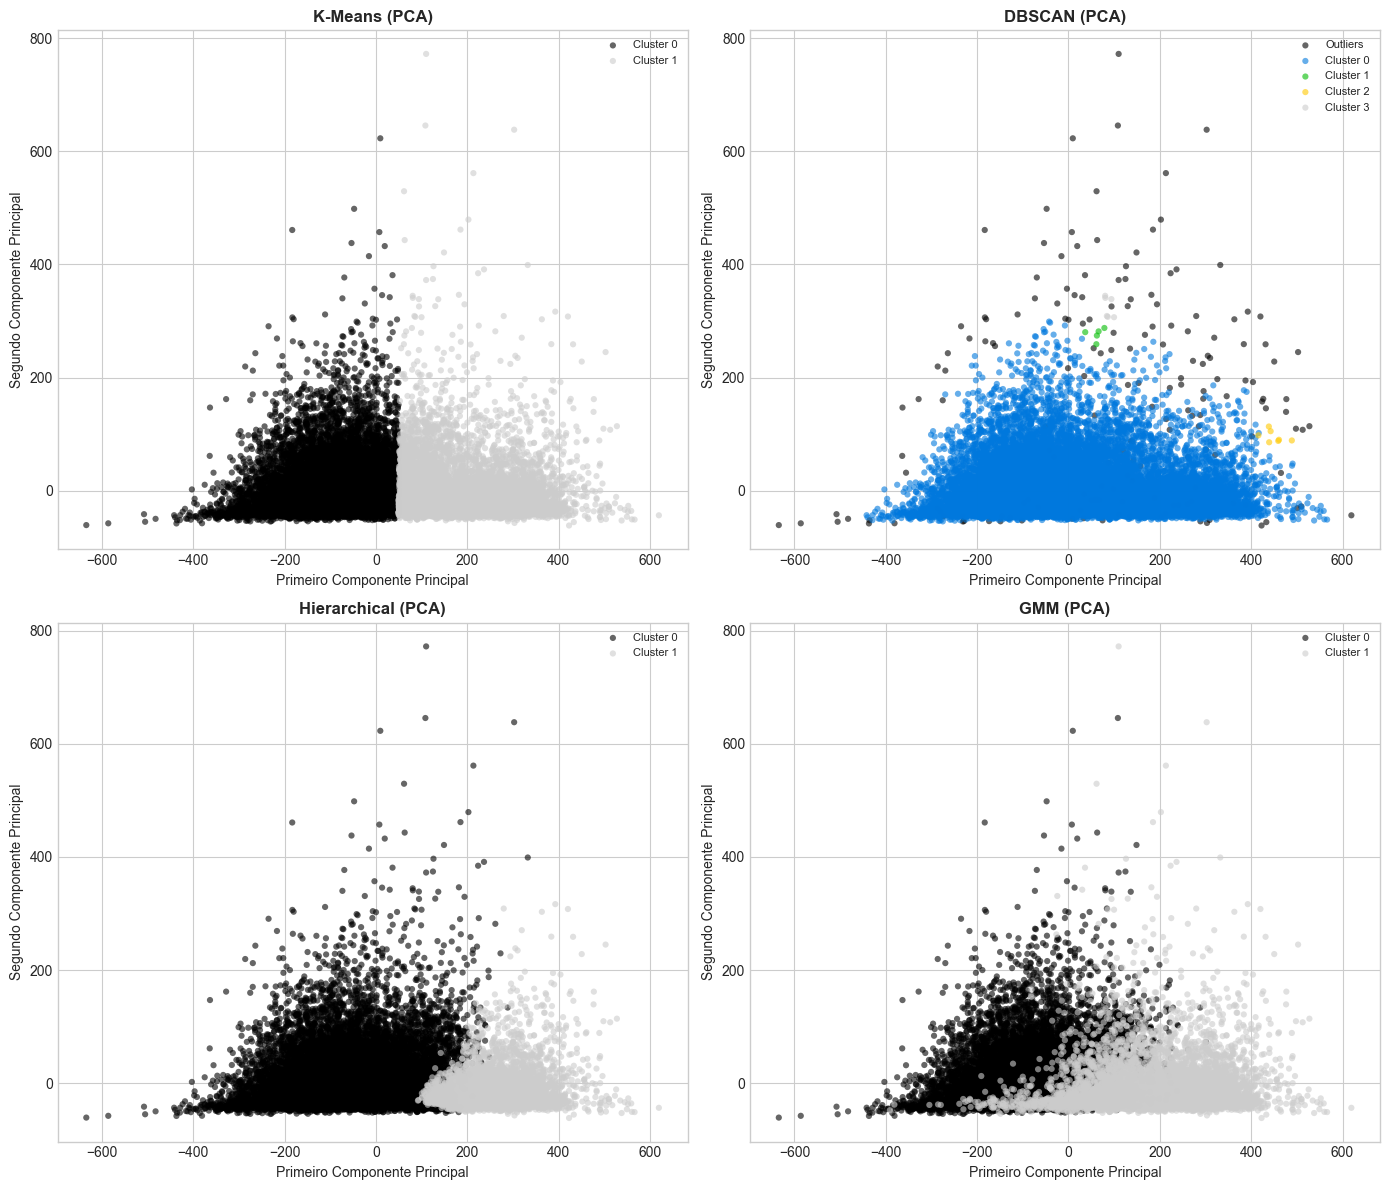


✅ Visualização PCA completa!


In [131]:
# Visualizar clusters no espaço PCA
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

algorithms_data = [
    ('K-Means', labels_kmeans),
    ('DBSCAN', labels_dbscan),
    ('Hierarchical', labels_hierarchical),
    ('GMM', labels_gmm)
]

for idx, (name, labels) in enumerate(algorithms_data):
    ax = axes[idx // 2, idx % 2]
    
    # Criar scatter plot
    unique_labels = sorted(set(labels))
    n_clusters_viz = len(unique_labels) - (1 if -1 in unique_labels else 0)
    
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # Preto para outliers
        
        class_mask = labels == k
        label_text = 'Outliers' if k == -1 else f'Cluster {k}'
        ax.scatter(X_pca[class_mask, 0], X_pca[class_mask, 1], 
                  c=[col], label=label_text, s=20, alpha=0.6, edgecolors='none')
    
    ax.set_xlabel('Primeiro Componente Principal', fontsize=10)
    ax.set_ylabel('Segundo Componente Principal', fontsize=10)
    ax.set_title(f'{name} (PCA)', fontsize=12, fontweight='bold')
    
    # Legenda compacta
    if len(unique_labels) <= 6:
        ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/clusters_pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualização PCA completa!")

In [132]:
# Aplicar t-SNE para visualização não-linear (amostra para performance)
print("🔽 Aplicando t-SNE para visualização não-linear...")
print("   (usando amostra de 500 escolas para performance)")

sample_size_tsne = min(500, len(X))
sample_idx_tsne = np.random.choice(len(X), sample_size_tsne, replace=False)

X_sample_tsne = X.iloc[sample_idx_tsne] if hasattr(X, 'iloc') else X[sample_idx_tsne]
X_pca_sample = X_pca[sample_idx_tsne]  # Usar PCA como init

# Aplicar t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, 
            max_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_sample_tsne)

print(f"   ✅ t-SNE aplicado em {sample_size_tsne} amostras")

🔽 Aplicando t-SNE para visualização não-linear...
   (usando amostra de 500 escolas para performance)
   ✅ t-SNE aplicado em 500 amostras


Usando X_tsne já calculado


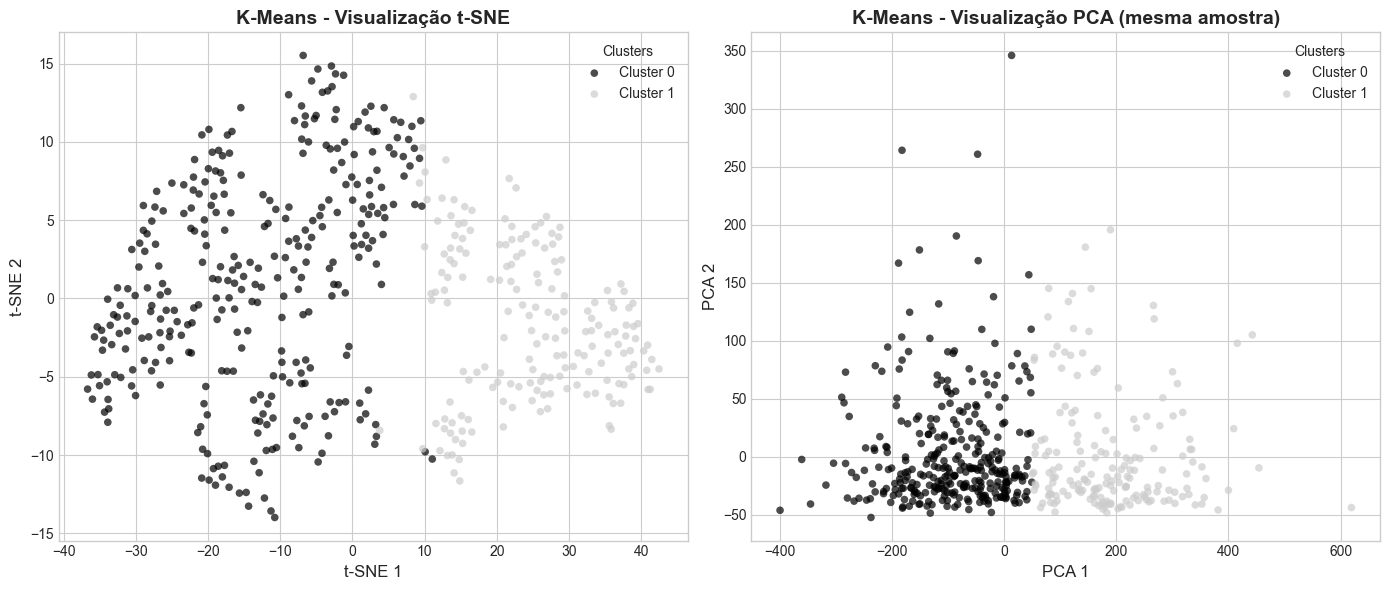


✅ Visualização t-SNE e PCA completa!


In [133]:
# Visualizar melhor algoritmo com t-SNE
# Verificar se X_tsne existe, senão recalcular
if 'X_tsne' not in locals():
    print('Recalculando t-SNE...')
    from sklearn.manifold import TSNE
    sample_size_tsne = min(500, len(X))
    sample_idx_tsne = np.random.choice(len(X), sample_size_tsne, replace=False)
    X_sample_tsne = X.iloc[sample_idx_tsne] if hasattr(X, 'iloc') else X[sample_idx_tsne]
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate='auto', init='pca')
    X_tsne = tsne.fit_transform(X_sample_tsne)
else:
    print('Usando X_tsne já calculado')

# Garantir que sample_idx_tsne existe
if 'sample_idx_tsne' not in locals():
    sample_idx_tsne = np.random.choice(len(X), min(500, len(X)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Labels do melhor algoritmo na amostra
if best_algorithm == 'K-Means':
    labels_sample = labels_kmeans[sample_idx_tsne]
elif best_algorithm == 'DBSCAN':
    labels_sample = labels_dbscan[sample_idx_tsne]
elif best_algorithm == 'Hierarchical':
    labels_sample = labels_hierarchical[sample_idx_tsne]
else:
    labels_sample = labels_gmm[sample_idx_tsne]

# Plot 1: t-SNE
unique_labels = sorted(set(labels_sample))
colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]
    class_mask = labels_sample == k
    label_text = 'Outliers' if k == -1 else f'Cluster {k}'
    axes[0].scatter(X_tsne[class_mask, 0], X_tsne[class_mask, 1], 
                   c=[col], label=label_text, s=30, alpha=0.7, edgecolors='none')

axes[0].set_xlabel('t-SNE 1', fontsize=12)
axes[0].set_ylabel('t-SNE 2', fontsize=12)
axes[0].set_title(f'{best_algorithm} - Visualização t-SNE', fontsize=14, fontweight='bold')
axes[0].legend(loc='best', title='Clusters')

# Plot 2: PCA dos mesmos pontos para comparação
X_pca_sample_viz = X_pca[sample_idx_tsne]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]
    class_mask = labels_sample == k
    label_text = 'Outliers' if k == -1 else f'Cluster {k}'
    axes[1].scatter(X_pca_sample_viz[class_mask, 0], X_pca_sample_viz[class_mask, 1], 
                   c=[col], label=label_text, s=30, alpha=0.7, edgecolors='none')

axes[1].set_xlabel('PCA 1', fontsize=12)
axes[1].set_ylabel('PCA 2', fontsize=12)
axes[1].set_title(f'{best_algorithm} - Visualização PCA (mesma amostra)', fontsize=14, fontweight='bold')
axes[1].legend(loc='best', title='Clusters')

plt.tight_layout()
plt.savefig('../reports/clusters_tsne_pca.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualização t-SNE e PCA completa!")

### Interpretação Preliminar dos Clusters

Baseado nas visualizações acima, podemos fazer algumas observações iniciais:

1. **Separação dos clusters**: Se os clusters estão bem separados nas visualizações, isso indica boa qualidade de clustering.
2. **Compactação**: Clusters mais compactos indicam maior coesão interna.
3. **Outliers (DBSCAN)**: Pontos identificados como outliers podem representar escolas atípicas.

Para uma análise mais aprofundada, execute o notebook `04_interpretation.ipynb`.

In [134]:
# Sumário final
print("\n" + "="*60)
print("RESUMO DO NOTEBOOK 03 - CLUSTERING")
print("="*60)
print(f"\n📊 Dados processados: {X.shape[0]} escolas x {X.shape[1]} features")
print(f"\n🎯 Número ótimo de clusters: k = {OPTIMAL_K}")
print(f"\n🏆 Melhor algoritmo: {best_algorithm}")
print(f"\n📈 Métricas do modelo escolhido:")

if best_algorithm == 'K-Means':
    print(f"   • Silhouette Score: {sil_kmeans:.4f}")
    print(f"   • Davies-Bouldin Index: {db_kmeans:.4f}")
    print(f"   • Calinski-Harabasz Index: {ch_kmeans:.2f}")
    print(f"   • Estabilidade (ARI médio): {ari_mean:.4f}")
elif best_algorithm == 'DBSCAN':
    print(f"   • Nº clusters: {n_clusters_db}")
    print(f"   • Outliers: {n_outliers_db} ({n_outliers_db/len(labels_dbscan)*100:.1f}%)")
    if sil_dbscan:
        print(f"   • Silhouette Score: {sil_dbscan:.4f}")
elif best_algorithm == 'Hierarchical':
    print(f"   • Silhouette Score: {sil_hierarchical:.4f}")
    print(f"   • Davies-Bouldin Index: {db_hierarchical:.4f}")
    print(f"   • Calinski-Harabasz Index: {ch_hierarchical:.2f}")
else:
    print(f"   • Silhouette Score: {sil_gmm:.4f}")
    print(f"   • Davies-Bouldin Index: {db_gmm:.4f}")
    print(f"   • Calinski-Harabasz Index: {ch_gmm:.2f}")
    print(f"   • BIC: {bic:.2f}")

print(f"\n💾 Arquivos salvos:")
print(f"   • Modelo: {MODELS_PATH / model_filename}")
print(f"   • Dados com clusters: {DATA_PATH / 'escolas_com_clusters.csv'}")
print(f"   • Relatório comparativo: {MODELS_PATH / 'algorithm_comparison.csv'}")
print(f"   • Visualizações: ../reports/")
print("\n" + "="*60)
print("✅ Notebook 03 finalizado com sucesso!")
print("="*60)


RESUMO DO NOTEBOOK 03 - CLUSTERING

📊 Dados processados: 23023 escolas x 8 features

🎯 Número ótimo de clusters: k = 2

🏆 Melhor algoritmo: K-Means

📈 Métricas do modelo escolhido:
   • Silhouette Score: 0.5198
   • Davies-Bouldin Index: 0.7059
   • Calinski-Harabasz Index: 33556.11
   • Estabilidade (ARI médio): 0.9999

💾 Arquivos salvos:
   • Modelo: ..\models\kmeans_model.pkl
   • Dados com clusters: ..\data\processed\escolas_com_clusters.csv
   • Relatório comparativo: ..\models\algorithm_comparison.csv
   • Visualizações: ../reports/

✅ Notebook 03 finalizado com sucesso!
